# ML Projekt
## Deborah Burri, Doga Kaya, Lea Hanimann, Elisa Sirigu

### 1. Daten laden

In [ ]:
import pandas as pd
df_basic = pd.read_csv("inputfiles/campaign_basic_information.csv")
df_channels = pd.read_csv("inputfiles/campaign_channels.csv")
df_snapshots = pd.read_csv("inputfiles/campaign_snapshots.csv")

### 2. Channels pivotieren
Die Tabelle **campaign_channels** liegt im sogenannten Long-Format vor, wobei eine Kampagne mehrere Zeilen besitzen kann, da sie über mehrere Marketingkanäle ausgespielt wird.

Für Machine Learning wird jedoch eine Struktur benötigt, bei der jede Instanz genau eine Zeile repräsentiert.

Daher wird die Tabelle mittels Pivot-Transformation in ein Wide-Format überführt.

Dabei gilt:
- Jeder Kanal wird zu einer eigenen Spalte
- Werte sind binär (0 oder 1)

Interpretation:
- 1 = Kanal wird verwendet
- 0 = Kanal wird nicht verwendet

Diese Transformation entspricht einem Multi-Hot-Encoding und ermöglicht es, kategoriale Informationen in numerischer Form in das Modell einzubringen.

In [ ]:
df_channels["value"] = 1

channels_pivot = df_channels.pivot_table(
    index="campaign_id",
    columns="channel",
    values="value",
    fill_value=0
).reset_index()

channels_pivot.columns.name = None

### 3. Snapshots pivotieren
Die Snapshot-Daten wurden von einem Long-Format in ein Wide-Format transformiert, sodass jede Kampagne durch genau eine Zeile repräsentiert wird. Dabei wurden die Werte der einzelnen Snapshots (1–4) in separate Spalten überführt. Dies ermöglicht es, die zeitliche Entwicklung einer Kampagne als Feature-Set zu modellieren und ist gleichzeitig kompatibel mit klassischen Machine-Learning-Algorithmen.

In [66]:
snapshots_impr = df_snapshots.pivot(
    index="campaign_id",
    columns="snapshot_number",
    values="impressions"
)
snapshots_impr.columns = [f"impressions_s{col}" for col in snapshots_impr.columns]

snapshots_days = df_snapshots.pivot(
    index="campaign_id",
    columns="snapshot_number",
    values="days_after_start"
)
snapshots_days.columns = [f"days_after_start_s{col}" for col in snapshots_days.columns]

snapshots_pivot = snapshots_impr.merge(
    snapshots_days,
    left_index=True,
    right_index=True 
).reset_index()

### 4. Alles zusammenführen

In [67]:
df = df_basic.merge(snapshots_pivot, on="campaign_id", how="left")
df = df.merge(channels_pivot, on="campaign_id", how="left")

### 5. Fehlende Werte in den Daten
Mithilfe von KI-tools haben wir die Daten durchgesacanned, um fehlende Werte zu finden und deren Anteil festzulegen.
Folgende fehlende Werte wurden gefunden:
- Impressions: 17 fehlende Werte von insgesamt 964 = 1.8% der Daten
- Channels: 393 fehlende Einträge von insgesamt 964 = 40.8% der Daten
- Category: 2 fehlende Einträge von insgesamt 241 = 0.8% der Daten

#### 5.1 Fehlende Channel-Spalten
Nach der Pivotierung entstehen leere Zellen für alle Channels, auf denen eine Kampagne nicht aktiv ist. Da 40.8% der möglichen Channel-Einträge nicht belegt sind, werden diese fehlenden Werte mit 0 ersetzt, um NaN-Werte im Datensatz zu vermeiden.

In [68]:
channel_cols = ["facebook", "instagram", "google_search", "google_display"]

for col in channel_cols:
    if col not in df.columns:
        df[col] = 0

df[channel_cols] = df[channel_cols].fillna(0).astype(int)

#### 5.2 Fehlende Impression-Spalten
Um die fehlenden Werte zu ersetzten haben wir uns überlegt, der jeweils fehlende Wert durch Berechnung des Wachstums mit den anderen zwei Werten zu interpretieren. Dafür mussten wir allerdings erst kontrollieren, ob es eine Kampagne gibt bei der mehr als ein Impression-Wert fehlt. Weil das nicht der fall war haben wir wie folgt den fehlenden Wert berechnet:
- impressions_s3 fehlt → Trend von S1→S2 wird zu S3 aufaddiert (s3 = s2 + (s2 - s1))
- impressions_s2 fehlt → Mittelwert von S1 und S3 (s2 = (s1 + s3) / 2)
- impressions_s1 fehlt → Trend von S2→S3 wird rückwärts auf S1 angewendet (s1 = s2 - (s3 - s2))

In [ ]:
def impute_missing_impressions(row):
    s1, s2, s3 = row["impressions_s1"], row["impressions_s2"], row["impressions_s3"]

    if pd.isna(s3) and not pd.isna(s1) and not pd.isna(s2):
        s3 = s2 + (s2 - s1)

    elif pd.isna(s2) and not pd.isna(s1) and not pd.isna(s3):
        s2 = (s1 + s3) / 2

    elif pd.isna(s1) and not pd.isna(s2) and not pd.isna(s3):
        s1 = s2 - (s3 - s2)

    row["impressions_s1"] = s1
    row["impressions_s2"] = s2
    row["impressions_s3"] = s3
    return row

df = df.apply(impute_missing_impressions, axis=1) #axis=0 wäre Spaltenweise

#### 5.3 Fehlende Category-Spalten
ToDo
Es sind die Kampagnen 231 und 232 – beide sehr ähnlich:

target: 20'000
budget: 100
region: switzerland
category: fehlt

Da category wahrscheinlich ein kategoriales Feature ist, hast du ein paar Optionen:

Zeilen droppen – da es nur 2 von 241 sind, kaum ein Verlust
Mit dem häufigsten Wert ersetzen – df["category"].fillna(df["category"].mode()[0])
Als eigene Kategorie behandeln – z.B. "unknown"

### 6. Zielvariable erstellen

Die Zielvariable `needs_intervention` beschreibt, ob eine Kampagne voraussichtlich Unterstützung benötigt.

Sie basiert auf den finalen Impressions (4. Snapshot):

- 1 = Ziel (90%) wird nicht erreicht
- 0 = Ziel wird erreicht

In [69]:
df["needs_intervention"] = (
    df["impressions_s4"] < 0.9 * df["target"]
).astype(int)

### 7. Feature Engineering

#### 7.1 Zeitfortschritt
Mit dieser Kennzahl wird der zeitliche Kontext der Kampagne messbar gemacht. Ein hoher Fortschritt bei den Impressions ist nur dann positiv zu bewerten, wenn er in einem angemessenen Verhältnis zur verstrichenen Zeit steht. Durch die Division der bereits vergangenen Tage durch die Gesamtlaufzeit erhalten wir einen Wert, der ausdrückt, wie viel der verfügbaren Zeit bereits "verbraucht" wurde.


In [ ]:
df["time_progress_s3"] = df["days_after_start_s3"] / df["days"]
df["remaining_days"] = df["days"] - df["days_after_start_s3"]

#### 7.2 Fortschritt relativ zum Ziel
Dieses Feature dient der Normalisierung der Zielerreichung. Da die Kampagnen sehr unterschiedliche Zielgrößen (target) haben, sind die absoluten Impressions-Zahlen nicht direkt vergleichbar. Die Ratio (Wertebereich meist zwischen 0 und 1) transformiert den aktuellen Stand in eine relative Kennzahl. Ein Wert von 0.7 bedeutet konsistent, dass 70 % des Ziels erreicht wurden, unabhängig davon, ob das Ziel bei tausend oder einer Million Impressions liegt. Das ermöglicht dem Modell, universelle Muster für Erfolg oder Misserfolg zu lernen.

In [70]:
df["impr_s3_ratio"] = df["impressions_s3"] / df["target"]

#### 7.3 Impressionen pro Tag
Hierbei handelt es sich um die Berechnung der aktuellen Ausspielungsgeschwindigkeit (Velocity). Während die vorangegangenen Ratios den bisherigen Status beschreiben, liefert die Geschwindigkeit pro Tag einen Indikator für die zukünftige Entwicklung. Sie zeigt auf, wie leistungsfähig die Kampagne im Durchschnitt bisher war. Das Modell benötigt diese Information, um zu beurteilen, ob das Tempo ausreicht, um die restliche Distanz zum Ziel in der verbleibenden Zeit zu überbrücken.

Wenn eine Kampagne gerade erst gestartet ist, ist `days_after_start_s3` = 0. Weil eine Division durch 0 zu einem Fehler führen könnte oder einen unendlichen Wert (inf) ergeben kann, wird mit `.replace(0, 1)` die Null temporär durch eine Eins ersetzt.

In [72]:
df["impr_per_day_s3"] = df["impressions_s3"] / df["days_after_start_s3"].replace(0, 1)

Wie sich die drei oberen Features unterscheiden:
`impr_s3_ratio` = 0.5 → 50% des Ziels erreicht
`time_progress_s3` = 0.8 → aber schon 80% der Zeit verbraucht, zu langsam
`impr_per_day_s3` = 10'000 → Velocity hilft dem Modell zu sehen, ob das Ziel noch erreichbar ist

#### 7.4 Benötigte Performance & Speed Ratio
Dieses Feature zeigt, wie viele Impressionen pro Tag ab dem dritten Snapshot noch notwendig wären, um das 90%-Ziel zu erreichen. Dafür werden die noch fehlenden Impressions mit der verbleibenden Zeit ins Verhältnis gesetzt.

Der `speed_ratio` setzt die benötigte Geschwindigkeit direkt in Relation zur bisherigen Performance und beantwortet damit die entscheidende Frage: Ist das aktuelle Tempo ausreichend, um das Ziel noch zu erreichen?

Interpretation der Ergebnisse:
- `1.0` bedeutet, dass man perfekt im Plan liegt
- `>1.0` bedeutet, dass man zu langsam ist und eingreifen sollte (z.B. 1.5 → 50% zu langsam)
- `<1.0` bedeutet, dass man schneller ist als nötig

Falls in einer vorherigen Rechnung ein unendlicher Wert (inf) entstanden ist, wird dieser mit `.replace([float("inf")], 0)` hart auf 0 zurückgesetzt.

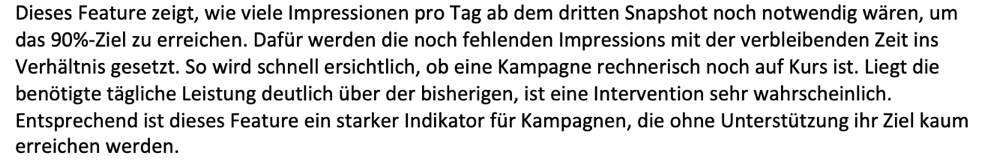

In [73]:
df["remaining_target"] = 0.9 * df["target"] - df["impressions_s3"]

df["required_impr_per_day"] = df["remaining_target"] / df["remaining_days"]
df["required_impr_per_day"] = df["required_impr_per_day"].replace([float("inf")], 0)

df["speed_ratio"] = df["required_impr_per_day"] / df["impr_per_day_s3"].replace(0, 1)

#### 7.5 Prognose
Das `projected_total` berechnet, wo die Kampagne am Ende ihrer Laufzeit enden wird. Die Berechnung basiert auf dem Trend der aktuellen Performance, was bedeutet, dass linear in die Zukunft geschaut wird.

`projected_ratio` vergleicht das Resultat vom `projected_total` mit dem Zielwert:
- `1.0` bedeutet Punktlandung
- `>1.0` bedeutet Überlieferung
- `<1.0` bedeutet Unterlieferung


In [ ]:
df["projected_total"] = df["impressions_s3"] + df["impr_per_day_s3"] * df["remaining_days"]
df["projected_ratio"] = df["projected_total"] / df["target"]

#### 7.6 Wachstum
Das Wachstums-Feature zeigt, wie sich die Impressionen zwischen den einzelnen Snapshot-Zeitpunkten entwickeln. Dafür wird geschaut, wie stark die Zunahme von Snapshot 1 zu 2 und von 2 zu 3 ist. So erkennt man relativ gut, ob eine Kampagne an Dynamik gewinnt oder eher an Schwung verliert.

Ein positiver Trend bedeutet, dass die Kampagne mit der Zeit besser performt. Ein negativer Trend hingegen ist ein frühes Warnsignal dafür, dass die Reichweite stagniert oder sogar zurückgeht. Das ist besonders hilfreich, weil das Modell damit auch Kampagnen erkennt, die aktuell noch solide aussehen, sich aber in eine ungünstige Richtung entwickeln.

In [74]:
df["growth_1_2"] = df["impressions_s2"] - df["impressions_s1"]
df["growth_2_3"] = df["impressions_s3"] - df["impressions_s2"]

#### 7.7 Wachstumsbeschleunigung
Die Wachstumsbeschleunigung geht noch einen Schritt weiter und schaut, ob sich dieser Trend verbessert oder verschlechtert. Dazu berechnen wir die Differenz zwischen den beiden Wachstumsphasen.

Ein positiver Wert zeigt, dass die Kampagne zunehmend schneller Impressionen aufbaut. Ein negativer Wert bedeutet dagegen, dass die Kampagne nicht mehr Reichweite gewonnen hat. Dieses Feature hilft dem Modell nicht nur zu verstehen, wie der aktuelle Trend aussieht, sondern auch, in welche Richtung er sich entwickelt.

In [75]:
df["growth_acceleration"] = df["growth_2_3"] - df["growth_1_2"]

#### 7.8 Budget Effizienz
Das Feature `budget_per_day` beschreibt, wie viel Budget pro Kampagnentag zur Verfügung steht. Dadurch wird das Gesamtbudget in Relation zur Laufzeit gesetzt und vergleichbar gemacht, unabhängig von der Kampagnendauer. Dieses Merkmal ist relevant, da Kampagnen mit höherem täglichem Budget tendenziell eine höhere Reichweite erzielen können und somit eine bessere Erfolgswahrscheinlichkeit haben.

In [ ]:
df["budget_per_day"] = df["budget"] / df["days"]

#### 7.9 Anzahl Channels
Mit `n_channels` wird erfasst, über wie viele Kanäle eine Kampagne gleichzeitig läuft. Die einzelnen Kanalindikatoren werden dabei zu einer Gesamtanzahl aggregiert. Dies ist wichtig, da eine breitere Streuung über mehrere Kanäle oft mit höherer Sichtbarkeit und besseren Ergebnissen verbunden ist.

In [ ]:
channel_cols = ["facebook", "instagram", "google_search", "google_display"]
df["n_channels"] = df[channel_cols].sum(axis=1)

#### 7.10 Google-Nutzung
Die Variable `google_any` zeigt, ob eine Kampagne mindestens einen Google-Kanal nutzt (Search oder Display). Dabei werden beide Kanäle zu einem binären Merkmal zusammengefasst. Dieses Merkmal ist aussagekräftig, da die Nutzung von Google-Plattformen häufig mit hoher Reichweite und gezielter Ansprache verbunden ist.

In [81]:
df["google_any"] = ((df["google_search"] + df["google_display"]) > 0).astype(int)

### 8. Data Leakage und Redundanz vermeiden
Um die Integrität des Modells sicherzustellen, müssen wir zwei kritische Aspekte beim Bereinigen des Datensatzes beachten:

#### 8.1 Data Leakage
Da `impressions_s4` den Endzustand der Kampagne darstellt, enthält dieses Feature Informationen aus der Zukunft. Würde das Modell mit diesen Daten trainiert, würde es "schummeln", da es das Ergebnis bereits kennt. Dies führt zu unrealistisch guten Ergebnissen im Training, die in der echten Anwendung (Prediction) versagen.

#### 8.2 Redundanz und Fokus
Durch das Feature Engineering haben wir bereits aussagekräftige Kennzahlen (wie Ratios und Geschwindigkeiten) erstellt. Die ursprünglichen Rohdaten tragen keinen weiteren Informationswert bei oder könnten das Modell sogar verwirren.
Unsere Tabelle haben wir auf diese Weise bereinigt, weil:
- Ein Modell darf niemals Zugriff auf Daten haben, die zum Zeitpunkt der Vorhersage noch nicht existieren,
- berechnete Features ersetzen die zugrunde liegenden Rohwerte, um Multikollinearität zu vermeiden,
- nicht-relevante Merkmale wie IDs oder Zeitstempel werden entfernt, um das Rauschen im Datensatz zu minimieren und
- bei einem Unsupervised-Learning-Ansatz (z. B. Clustering) werden auch Zielwerte (Targets) entfernt, damit das Modell rein auf Basis der Muster in den Daten lernt.

In [82]:
df = df.drop(columns=[
    # Data Leakage
    "impressions_s4",
    "days_after_start_s4",

    # Rohdaten
    "impressions_s1",
    "impressions_s2",
    "impressions_s3",
    "days_after_start_s1",
    "days_after_start_s2",
    "days_after_start_s3",
    "target",
    "remaining_target",
    "projected_total",

    # IDs & Zeitstempel
    "campaign_id",
    "start_week",
    "end_week",
    "end_month",
])

### 9. Kontrolle

In [83]:
df

,budget,start_month,days,region,category,facebook,google_display,google_search,instagram,needs_intervention,...,required_impr_per_day,growth_1_2,growth_2_3,growth_acceleration,projected_total,projected_ratio,speed_ratio,budget_per_day,n_channels,google_any
0,20400,9,57,germany,other,0,0,0,1,0,...,-389316.928571,1445833.0,1747435.0,301602.0,1.209253e+07,2.963856,-1.835105,357.894737,1,0
1,18300,12,154,austria,conference,1,1,1,1,0,...,4151.868421,675271.0,608187.0,-67084.0,4.163614e+06,1.137600,0.153566,118.831169,4,1
2,10900,5,33,switzerland,festival,1,1,1,1,0,...,46007.875000,334042.0,408846.0,74804.0,2.103997e+06,0.965136,0.721607,330.303030,4,1
3,10700,3,110,germany,conference,1,1,1,1,0,...,7526.464286,332777.0,373221.0,40444.0,2.300957e+06,1.075214,0.359812,97.272727,4,1
4,10600,5,473,germany,comedy,1,0,1,1,0,...,2056.983051,291655.0,430190.0,138535.0,2.218804e+06,1.046606,0.438503,22.410148,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236,100,10,18,germany,conference,1,0,1,0,1,...,1415.750000,5182.0,4468.0,-714.0,1.586186e+04,0.793093,1.606590,5.555556,2,1
237,100,9,70,germany,comedy,1,0,0,1,0,...,441.333333,5874.0,1501.0,-4373.0,1.353692e+04,0.676846,2.282153,1.428571,2,0
238,100,12,21,switzerland,theatre,1,0,0,0,1,...,676.600000,1479.0,5006.0,3527.0,1.918481e+04,0.959241,0.740617,4.761905,1,0
239,100,4,29,germany,festival,1,0,0,0,0,...,395.000000,7527.0,3160.0,-4367.0,2.008250e+04,1.004125,0.570397,3.448276,1,0


In [84]:
df.to_csv("inputfiles/beab_datensatz.csv", index=False)